# EDA — commerces-par-commune.csv
Urban Data Explorer · Commerces (Base Permanente des Équipements)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import json

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

## 1. Chargement

In [18]:
# ⚠️ Change le chemin si besoin
FILE = '../brute/Score densité de services du quotidien/les-commerces-par-commune-ou-arrondissement-base-permanente-des-equipements.csv'

df = pd.read_csv(FILE, sep=None, engine='python')
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)
print(f'Shape : {df.shape}')
df.head()

Shape : (1300, 33)


,departement,departement_commune,libelle_de_commune,arrondissement,canton_ville,zone_d_emploi,unite_urbaine,population_2010,hypermarche,supermarche,...,magasin_d_articles_de_sports_et_de_loisirs,magasin_de_revetements_murs_et_sols,droguerie_quincaillerie_bricolage,parfumerie,horlogerie_bijouterie,fleuriste,magasin_d_optique,station_service,geo_point_2d,geo_shape
0,94,94074,Valenton,941,9447,1118,851,12081,0,3,...,0,0,0,2,0,1,0,2,"48.7528724020014,2.461294795734387","{""coordinates"": [[[2.472978586691335, 48.72757..."
1,95,95427,Montmagny,952,9509,56,851,14250,0,1,...,1,0,0,0,1,2,1,1,"48.96991958406158,2.346075317904123","{""coordinates"": [[[2.333312950123798, 48.95538..."
2,91,91619,Torfou,911,9109,1115,91000,272,0,0,...,0,0,0,0,0,0,0,0,"48.53204942675463,2.234472045873927","{""coordinates"": [[[2.235403341803649, 48.52167..."
3,95,95183,Courdimanche,953,9539,1119,851,6495,0,0,...,0,0,1,1,0,0,0,0,"49.040676792977436,1.9994435918049531","{""coordinates"": [[[1.9915275372253372, 49.0237..."
4,77,77197,Frétoy,773,7723,1103,77000,155,0,0,...,0,0,0,0,0,0,0,0,"48.706357723270294,3.202607504719354","{""coordinates"": [[[3.212320353639203, 48.69176..."


## 2. Extraction des coordonnées (centroïde geo_point_2d)
Le champ `geo_shape` est un **Polygon** (contour de la commune), on utilise donc le centroïde `geo_point_2d` (format `lat,lon`).

In [6]:
geo = df['geo_point_2d'].str.split(',', expand=True).astype(float)
df['latitude']  = geo[0]
df['longitude'] = geo[1]
print('Bornes geographiques :')
print(f"  Latitude  : {df['latitude'].min():.4f} -> {df['latitude'].max():.4f}")
print(f"  Longitude : {df['longitude'].min():.4f} -> {df['longitude'].max():.4f}")
df[['libelle_de_commune', 'latitude', 'longitude']].head()

Bornes geographiques :
  Latitude  : 48.1408 -> 49.2132
  Longitude : 1.4806 -> 3.4892


,libelle_de_commune,latitude,longitude
0,Valenton,48.752872,2.461295
1,Montmagny,48.969920,2.346075
2,Torfou,48.532049,2.234472
3,Courdimanche,49.040677,1.999444
4,Frétoy,48.706358,3.202608


## 3. Infos générales

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   departement                                     1300 non-null   int64  
 1   departement_commune                             1300 non-null   int64  
 2   libelle_de_commune                              1300 non-null   object 
 3   arrondissement                                  1300 non-null   int64  
 4   canton_ville                                    1300 non-null   int64  
 5   zone_d_emploi                                   1300 non-null   int64  
 6   unite_urbaine                                   1300 non-null   int64  
 7   population_2010                                 1300 non-null   int64  
 8   hypermarche                                     1300 non-null   int64  
 9   supermarche                              

In [8]:
df.describe(include='all')

,departement,departement_commune,libelle_de_commune,arrondissement,canton_ville,zone_d_emploi,unite_urbaine,population_2010,hypermarche,supermarche,...,droguerie_quincaillerie_bricolage,parfumerie,horlogerie_bijouterie,fleuriste,magasin_d_optique,station_service,geo_point_2d,geo_shape,latitude,longitude
count,1300.000000,1300.000000,1300,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,...,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300,1300,1300.000000,1300.000000
unique,NaN,NaN,1296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1300,1300,NaN,NaN
top,NaN,NaN,Marolles-en-Brie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,"48.7528724020014,2.461294795734387","{""coordinates"": [[[2.472978586691335, 48.72757...",NaN,NaN
freq,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,NaN,NaN
mean,83.365385,83645.627692,NaN,835.930769,8358.317692,986.340000,54159.081538,9066.333846,0.143846,1.247692,...,0.757692,1.516923,1.516923,2.183846,2.106154,0.691538,NaN,NaN,48.761785,2.433601
std,7.746337,7740.687821,NaN,77.385122,777.385541,338.702367,38645.685943,21316.429683,0.431711,3.502143,...,2.688423,7.142378,7.936557,6.700859,7.166735,1.336785,NaN,NaN,0.243625,0.472419
min,75.000000,75101.000000,NaN,751.000000,7599.000000,56.000000,260.000000,28.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,48.140770,1.480637
25%,77.000000,77313.750000,NaN,773.000000,7722.000000,1103.000000,851.000000,544.500000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,48.574843,2.073553
50%,78.000000,78310.500000,NaN,781.000000,7810.000000,1108.000000,77000.000000,1339.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,48.805239,2.402338
75%,91.000000,91645.750000,NaN,913.000000,9135.000000,1115.000000,78000.000000,6775.500000,0.000000,1.000000,...,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,NaN,NaN,48.956707,2.793340


## 4. Valeurs manquantes

In [9]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print('✅ Aucune valeur manquante')
else:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.4)))
    ax.barh(missing.index, missing.values, color='#378ADD')
    ax.set_xlabel('% manquant')
    ax.set_title('Valeurs manquantes par colonne')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    plt.tight_layout()
    plt.show()
    display(missing.rename('% manquant').to_frame())

✅ Aucune valeur manquante


## 5. Doublons

In [10]:
n_dup = df.duplicated().sum()
print(f'Doublons exacts          : {n_dup} ({n_dup/len(df)*100:.2f}%)')
n_dup_geo = df.duplicated(subset=['latitude','longitude']).sum()
print(f'Doublons sur coordonnees : {n_dup_geo} ({n_dup_geo/len(df)*100:.2f}%)')
n_dup_com = df.duplicated(subset=['departement_commune']).sum()
print(f'Doublons sur code commune: {n_dup_com}')

Doublons exacts          : 0 (0.00%)
Doublons sur coordonnees : 0 (0.00%)
Doublons sur code commune: 0


## 6. Détection des colonnes clés

In [11]:
def find_col(df, *keywords):
    for kw in keywords:
        match = [c for c in df.columns if kw.lower() in c.lower()]
        if match: return match[0]
    return None

# colonnes administratives (a exclure du comptage commerces)
ADMIN = ['departement','departement_commune','arrondissement','canton_ville',
         'zone_d_emploi','unite_urbaine','population_2010']
commerce_cols = [c for c in df.select_dtypes('int64').columns if c not in ADMIN]

col_map = {
    'commune'    : find_col(df, 'libelle_de_commune', 'commune'),
    'population' : find_col(df, 'population'),
    'latitude'   : find_col(df, 'latitude', 'lat'),
    'longitude'  : find_col(df, 'longitude', 'lon', 'lng'),
}
for k, v in col_map.items():
    status = '✅' if v else '❌'
    print(f'{status}  {k:12s} → {v}')
print(f'\nNb de types de commerces detectes : {len(commerce_cols)}')

✅  commune      → libelle_de_commune
✅  population   → population_2010
✅  latitude     → latitude
✅  longitude    → longitude

Nb de types de commerces detectes : 23


## 7. Total de commerces par type

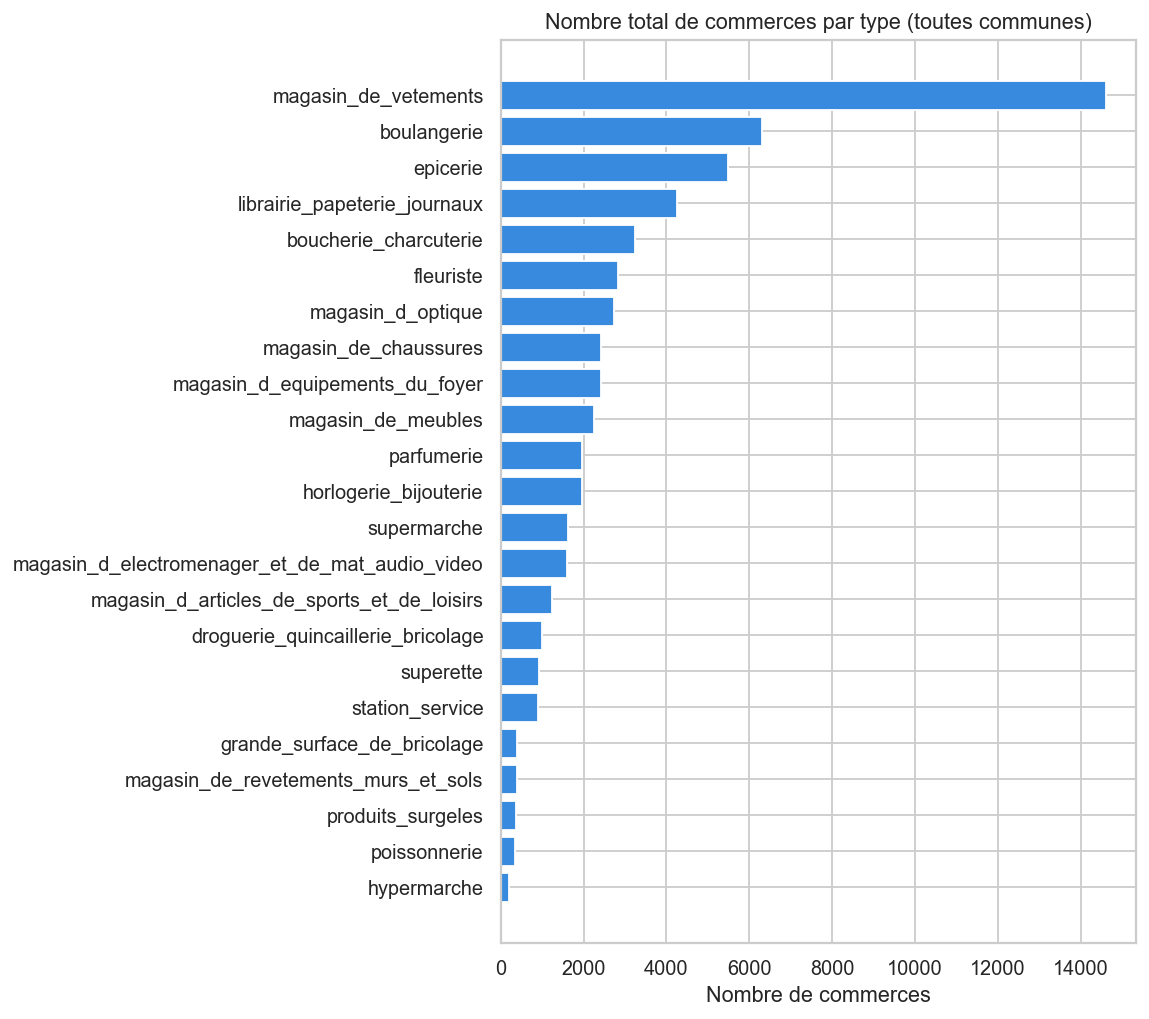

,Total
magasin_de_vetements,14613
boulangerie,6299
epicerie,5491
librairie_papeterie_journaux,4248
boucherie_charcuterie,3233
fleuriste,2839
magasin_d_optique,2738
magasin_de_chaussures,2424
magasin_d_equipements_du_foyer,2410
magasin_de_meubles,2244


In [12]:
totaux = df[commerce_cols].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(totaux.index, totaux.values, color='#378ADD')
ax.set_title('Nombre total de commerces par type (toutes communes)')
ax.set_xlabel('Nombre de commerces')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
display(totaux.rename('Total').to_frame())

## 8. Top 20 communes par nombre de commerces

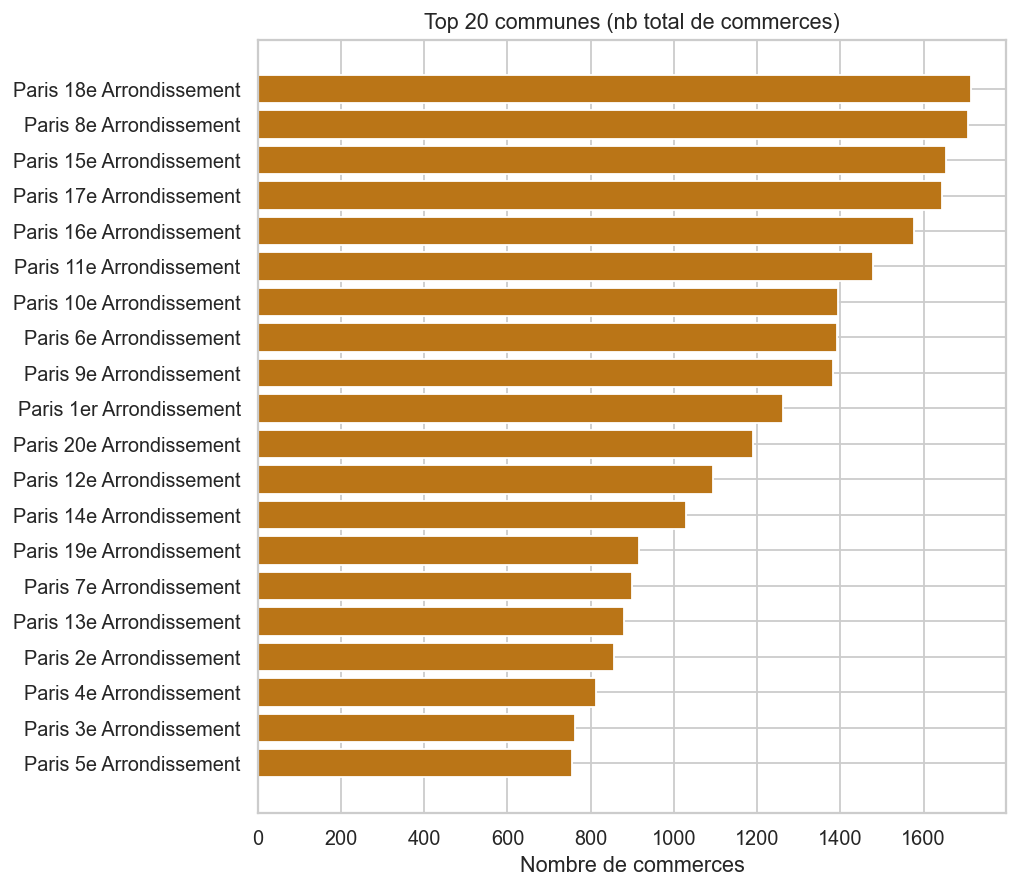

,libelle_de_commune,total_commerces,population_2010
0,Paris 18e Arrondissement,1713,202685
1,Paris 8e Arrondissement,1707,41280
2,Paris 15e Arrondissement,1654,236715
3,Paris 17e Arrondissement,1644,169325
4,Paris 16e Arrondissement,1577,171124
5,Paris 11e Arrondissement,1478,153202
6,Paris 10e Arrondissement,1395,95394
7,Paris 6e Arrondissement,1393,43451
8,Paris 9e Arrondissement,1383,60139
9,Paris 1er Arrondissement,1262,17308


In [13]:
df['total_commerces'] = df[commerce_cols].sum(axis=1)
top = df.nlargest(20, 'total_commerces')
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top['libelle_de_commune'].astype(str), top['total_commerces'], color='#BA7517')
ax.set_title('Top 20 communes (nb total de commerces)')
ax.set_xlabel('Nombre de commerces')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
display(top[['libelle_de_commune','total_commerces','population_2010']].reset_index(drop=True))

## 9. Commerces vs population

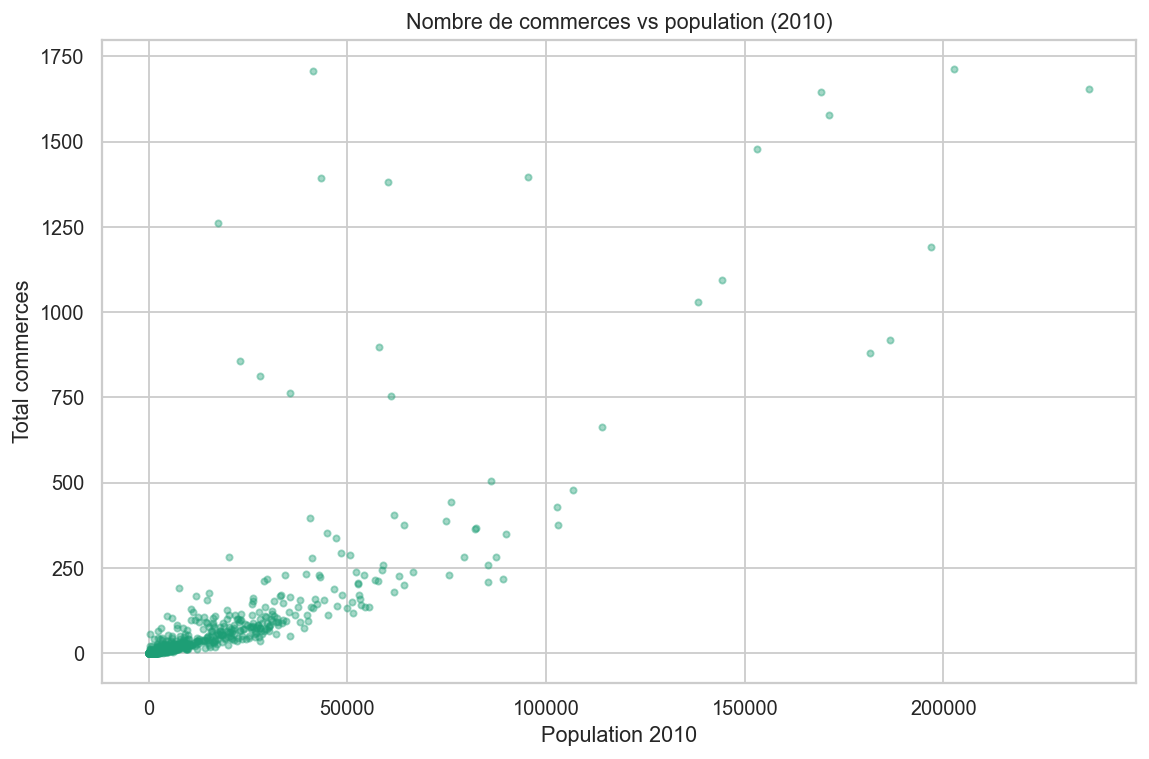

Correlation population / nb commerces : 0.816


In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df['population_2010'], df['total_commerces'], s=12, alpha=0.4, color='#1D9E75')
ax.set_title('Nombre de commerces vs population (2010)')
ax.set_xlabel('Population 2010')
ax.set_ylabel('Total commerces')
plt.tight_layout()
plt.show()
corr = df['population_2010'].corr(df['total_commerces'])
print(f'Correlation population / nb commerces : {corr:.3f}')

## 11. Résumé final

In [16]:
print('=' * 50)
print('RESUME EDA — commerces-par-commune.csv')
print('=' * 50)
print(f'  Lignes (communes)   : {len(df):,}')
print(f'  Colonnes            : {len(df.columns)}')
print(f'  Types de commerces  : {len(commerce_cols)}')
print(f'  Total commerces     : {int(df[commerce_cols].sum().sum()):,}')
print(f'  Doublons exacts     : {df.duplicated().sum()}')
missing_count = (df.isnull().sum() > 0).sum()
print(f'  Cols avec NaN       : {missing_count}')
print(f'  Communes Paris (75) : {(df["departement"]==75).sum()}')
print(f'  Population totale    : {int(df["population_2010"].sum()):,}')
if lat_col and lon_col:
    print(f'  Lat range           : {df[lat_col].min():.4f} → {df[lat_col].max():.4f}')
    print(f'  Lon range           : {df[lon_col].min():.4f} → {df[lon_col].max():.4f}')
print('=' * 50)

RESUME EDA — commerces-par-commune.csv
  Lignes (communes)   : 1,300
  Colonnes            : 36
  Types de commerces  : 23
  Total commerces     : 59,419
  Doublons exacts     : 0
  Cols avec NaN       : 0
  Communes Paris (75) : 20
  Population totale    : 11,786,234
  Lat range           : 48.1408 → 49.2132
  Lon range           : 1.4806 → 3.4892
